In [1]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()

wr6N1 = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR6000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2560000/288d35a1-5203-4106-bce7-00d3e7d1c102.root"
wr6N3 = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR6000_N300_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2810000/42fb9de2-2961-4139-a93d-4b9726366b82.root"


wr8N1 = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR8000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2810000/7ffe6534-4feb-4352-b104-bcdf6b048301.root"
wr8N3 = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR8000_N300_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/120000/60b83390-192f-4ec4-a6a7-cad776075b32.root"
wr8N5 = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR8000_N500_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2810000/68e11e35-8b9c-4b7f-838e-39742074ce32.root"


file1 = uproot.open(wr6N1)
file2 = uproot.open(wr6N3)
file3 = uproot.open(wr8N1)
file4 = uproot.open(wr8N3)
file5 = uproot.open(wr8N5)





In [2]:
samples = {
    "WR6000_N100": file1,
    "WR6000_N300": file2,
    "WR8000_N100": file3,
    "WR8000_N300": file4,
    "WR8000_N500": file5,
}

common_threshold = 800.0

sample_thresholds = {
    "WR6000_N100": 4000.0,
    "WR6000_N300": 4000.0,
    "WR8000_N100": 6000.0,
    "WR8000_N300": 6000.0,
    "WR8000_N500": 6000.0,
}

def get_lhe_mass(root_file):
    events = root_file["Events"]
    masses = []

    for lhe in tqdm(
        events.iterate(
            filter_name=["LHEPart_pt", "LHEPart_eta", "LHEPart_phi", "LHEPart_mass"],
            step_size="100 MB",
            library="ak",
        ),
        desc="Reading LHE",
    ):
        lhe_p4 = ak.zip(
            {
                "pt": lhe["LHEPart_pt"],
                "eta": lhe["LHEPart_eta"],
                "phi": lhe["LHEPart_phi"],
                "mass": lhe["LHEPart_mass"],
            },
            with_name="Momentum4D",
        )

        lhe_sum_p4 = ak.sum(lhe_p4, axis=1)
        chunk_mass = ak.to_numpy(lhe_sum_p4.mass)
        masses.append(chunk_mass[np.isfinite(chunk_mass)])

    return np.concatenate(masses) if masses else np.array([])

results = {}

for sample_name, root_file in samples.items():
    print(f"\nProcessing {sample_name}")
    lhe_mass = get_lhe_mass(root_file)
    sample_threshold = sample_thresholds[sample_name]
    n_total = len(lhe_mass)
    n_below_800 = int(np.count_nonzero(lhe_mass < common_threshold))
    frac_below_800 = n_below_800 / n_total if n_total else np.nan
    n_below_sample_threshold = int(np.count_nonzero(lhe_mass < sample_threshold))
    frac_below_sample_threshold = n_below_sample_threshold / n_total if n_total else np.nan

    results[sample_name] = {
        "mass": lhe_mass,
        "common_threshold": common_threshold,
        "sample_threshold": sample_threshold,
        "n_total": n_total,
        "n_below_800": n_below_800,
        "frac_below_800": frac_below_800,
        "n_below_sample_threshold": n_below_sample_threshold,
        "frac_below_sample_threshold": frac_below_sample_threshold,
    }

    print(f"  Number of events: {n_total}")
    print(f"  Events with mass < {common_threshold:.0f} GeV: {n_below_800}")
    print(f"  Fraction with mass < {common_threshold:.0f} GeV: {frac_below_800:.6f}")
    print(f"  Events with mass < {sample_threshold:.0f} GeV: {n_below_sample_threshold}")
    print(f"  Fraction with mass < {sample_threshold:.0f} GeV: {frac_below_sample_threshold:.6f}")
    print(f"  First 10 summed LHE masses [GeV]: {lhe_mass[:10]}")


Processing WR6000_N100


Reading LHE: 1it [00:00,  4.56it/s]


  Number of events: 6000
  Events with mass < 800 GeV: 1666
  Fraction with mass < 800 GeV: 0.277667
  Events with mass < 4000 GeV: 3814
  Fraction with mass < 4000 GeV: 0.635667
  First 10 summed LHE masses [GeV]: [ 692.9306  1772.6334  2117.1934  5811.2915   824.78925  388.976
 2120.8555   482.85376 6002.059    433.77884]

Processing WR6000_N300


Reading LHE: 1it [00:00, 11.24it/s]


  Number of events: 1000
  Events with mass < 800 GeV: 134
  Fraction with mass < 800 GeV: 0.134000
  Events with mass < 4000 GeV: 559
  Fraction with mass < 4000 GeV: 0.559000
  First 10 summed LHE masses [GeV]: [ 914.0428   998.55035 6463.033   2219.3704   636.8968  6151.522
 2979.126   6141.9736  6033.3506  3458.045  ]

Processing WR8000_N100


...

  Number of events: 10000
  Events with mass < 800 GeV: 4089
  Fraction with mass < 800 GeV: 0.408900
  Events with mass < 6000 GeV: 8912
  Fraction with mass < 6000 GeV: 0.891200
  First 10 summed LHE masses [GeV]: [ 431.7591   867.4738   626.9439   787.9541   997.2379   242.17453
 3727.1416   899.74457  616.99225 1263.7784 ]

Processing WR8000_N300


Reading LHE: 1it [00:00,  9.57it/s]


  Number of events: 3000
  Events with mass < 800 GeV: 586
  Fraction with mass < 800 GeV: 0.195333
  Events with mass < 6000 GeV: 2541
  Fraction with mass < 6000 GeV: 0.847000
  First 10 summed LHE masses [GeV]: [ 970.4862 8035.506  7932.9375  650.7743  736.6337  961.2848 1963.7985
 7911.98   1843.4293 1224.7664]

Processing WR8000_N500


Reading LHE: 1it [00:00,  3.45it/s]

  Number of events: 27000
  Events with mass < 800 GeV: 1754
  Fraction with mass < 800 GeV: 0.064963
  Events with mass < 6000 GeV: 21543
  Fraction with mass < 6000 GeV: 0.797889
  First 10 summed LHE masses [GeV]: [1791.9207 3379.2063  757.8175 2884.8486 1575.957  8215.998  7989.6704
 2000.3254 1687.7413 1227.9296]


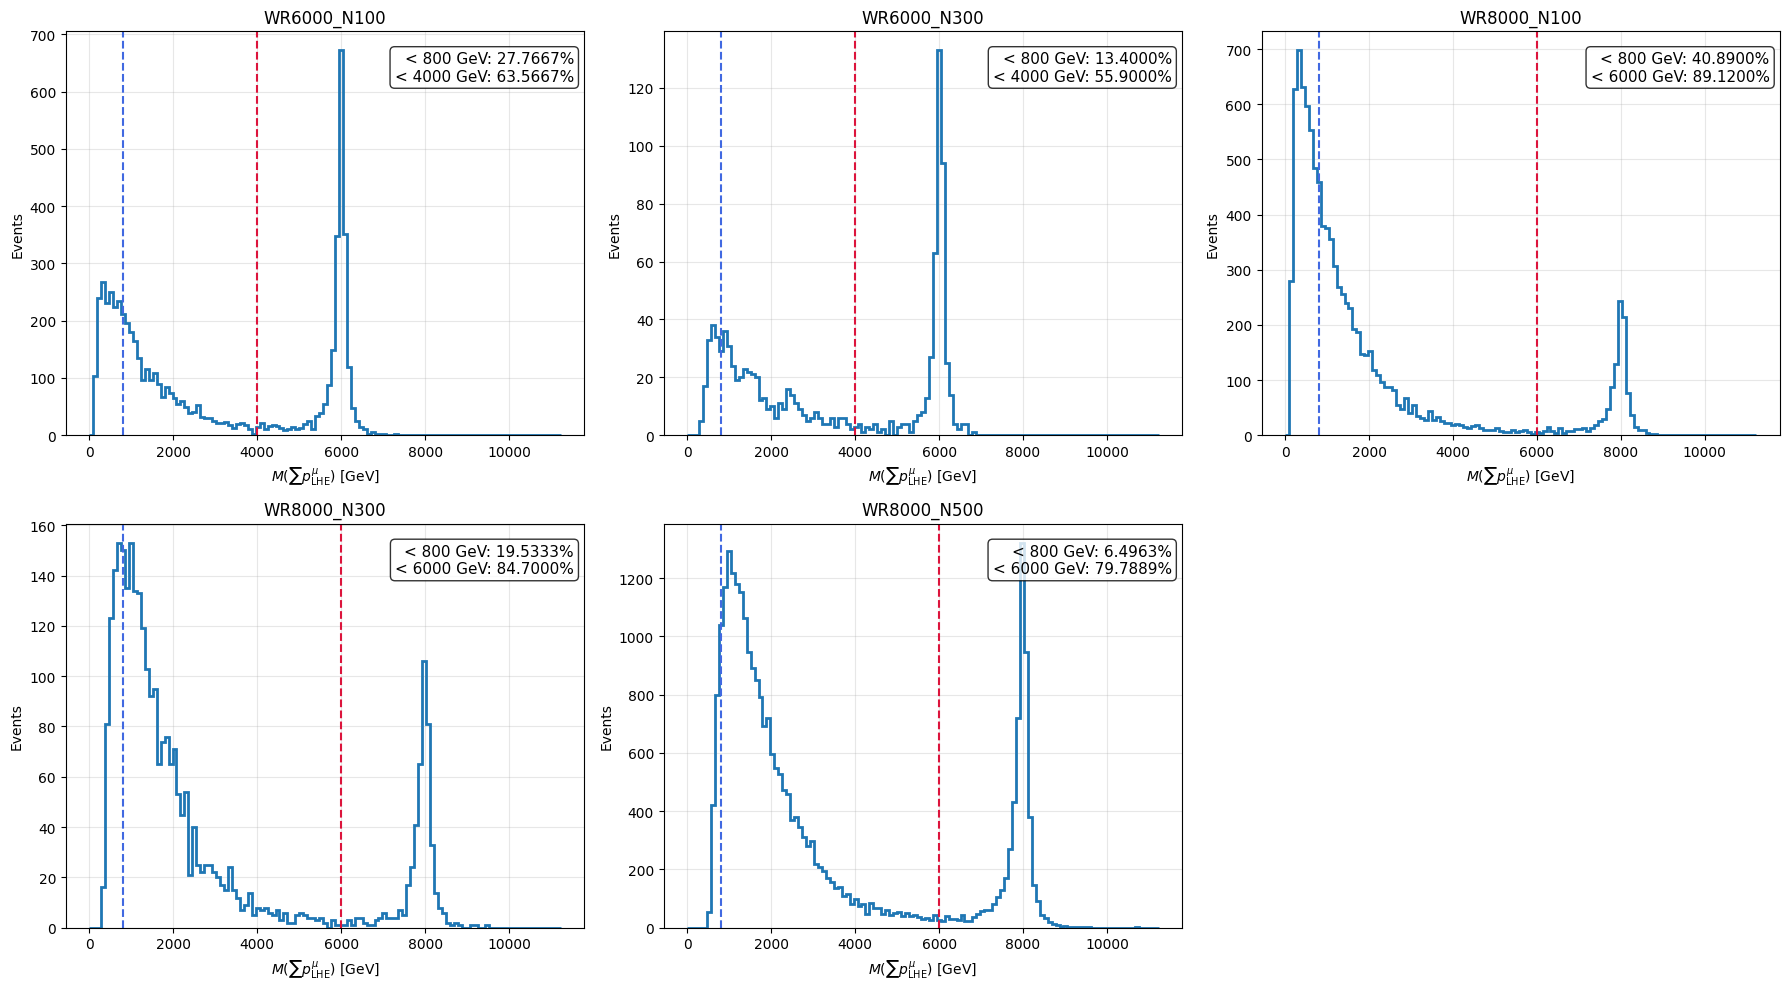


Summary
WR6000_N100: total=6000, below_800=1666, fraction_800=0.277667, below_4000=3814, fraction_4000=0.635667
WR6000_N300: total=1000, below_800=134, fraction_800=0.134000, below_4000=559, fraction_4000=0.559000
WR8000_N100: total=10000, below_800=4089, fraction_800=0.408900, below_6000=8912, fraction_6000=0.891200
WR8000_N300: total=3000, below_800=586, fraction_800=0.195333, below_6000=2541, fraction_6000=0.847000
WR8000_N500: total=27000, below_800=1754, fraction_800=0.064963, below_6000=21543, fraction_6000=0.797889


In [3]:
all_masses = [info["mass"] for info in results.values() if len(info["mass"]) > 0]
global_max = max(np.max(mass) for mass in all_masses) if all_masses else max(sample_thresholds.values())
bins = np.linspace(0.0, global_max * 1.05, 120)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (sample_name, info) in zip(axes, results.items()):
    mass = info["mass"]
    common_threshold = info["common_threshold"]
    sample_threshold = info["sample_threshold"]
    ax.hist(mass, bins=bins, histtype="step", linewidth=2)
    ax.axvline(common_threshold, color="royalblue", linestyle="--", linewidth=1.5)
    ax.axvline(sample_threshold, color="crimson", linestyle="--", linewidth=1.5)
    ax.set_title(sample_name)
    ax.set_xlabel(r"$M(\sum p^{\mu}_{\mathrm{LHE}})$ [GeV]")
    ax.set_ylabel("Events")
    ax.grid(alpha=0.3)
    ax.text(
        0.98,
        0.95,
        f"< {common_threshold:.0f} GeV: {info['frac_below_800']:.4%}\n"
        f"< {sample_threshold:.0f} GeV: {info['frac_below_sample_threshold']:.4%}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

for ax in axes[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\nSummary")
for sample_name, info in results.items():
    print(
        f"{sample_name}: total={info['n_total']}, "
        f"below_{info['common_threshold']:.0f}={info['n_below_800']}, "
        f"fraction_{info['common_threshold']:.0f}={info['frac_below_800']:.6f}, "
        f"below_{info['sample_threshold']:.0f}={info['n_below_sample_threshold']}, "
        f"fraction_{info['sample_threshold']:.0f}={info['frac_below_sample_threshold']:.6f}"
    )

In [42]:
samples = {
    #"WR6000_N100": file1,
    #"WR6000_N300": file2,
    #"WR8000_N100": file3,
    #"WR8000_N300": file4,
    "WR8000_N500": file5,
}

common_threshold = 800.0

sample_thresholds = {
    #"WR6000_N100": 4000.0,
    #"WR6000_N300": 4000.0,
    #"WR8000_N100": 6000.0,
    #"WR8000_N300": 6000.0,
    "WR8000_N500": 6000.0,
}

def get_lhe_mass(root_file):
    events = root_file["Events"]
    masses = []

    for lhe in tqdm(
        events.iterate(
            filter_name=["LHEPart_pt", "LHEPart_eta", "LHEPart_phi", "LHEPart_mass"],
            step_size="100 MB",
            library="ak",
        ),
        desc="Reading LHE",
    ):
        lhe_p4 = ak.zip(
            {
                "pt": lhe["LHEPart_pt"],
                "eta": lhe["LHEPart_eta"],
                "phi": lhe["LHEPart_phi"],
                "mass": lhe["LHEPart_mass"],
            },
            with_name="Momentum4D",
        )

        lhe_sum_p4 = ak.sum(lhe_p4, axis=1)
        chunk_mass = ak.to_numpy(lhe_sum_p4.mass)
        masses.append(chunk_mass[np.isfinite(chunk_mass)])

    return np.concatenate(masses) if masses else np.array([])

results = {}

for sample_name, root_file in samples.items():
    print(f"\nProcessing {sample_name}")
    lhe_mass = get_lhe_mass(root_file)
    sample_threshold = sample_thresholds[sample_name]
    n_total = len(lhe_mass)
    n_below_800 = int(np.count_nonzero(lhe_mass < common_threshold))
    frac_below_800 = n_below_800 / n_total if n_total else np.nan
    n_below_sample_threshold = int(np.count_nonzero(lhe_mass < sample_threshold))
    frac_below_sample_threshold = n_below_sample_threshold / n_total if n_total else np.nan

    results[sample_name] = {
        "mass": lhe_mass,
        "common_threshold": common_threshold,
        "sample_threshold": sample_threshold,
        "n_total": n_total,
        "n_below_800": n_below_800,
        "frac_below_800": frac_below_800,
        "n_below_sample_threshold": n_below_sample_threshold,
        "frac_below_sample_threshold": frac_below_sample_threshold,
    }

    print(f"  Number of events: {n_total}")
    print(f"  Events with mass < {common_threshold:.0f} GeV: {n_below_800}")
    print(f"  Fraction with mass < {common_threshold:.0f} GeV: {frac_below_800:.6f}")
    print(f"  Events with mass < {sample_threshold:.0f} GeV: {n_below_sample_threshold}")
    print(f"  Fraction with mass < {sample_threshold:.0f} GeV: {frac_below_sample_threshold:.6f}")
    print(f"  First 10 summed LHE masses [GeV]: {lhe_mass[:10]}")


Processing WR8000_N500


Reading LHE: 1it [00:00,  5.72it/s]

  Number of events: 27000
  Events with mass < 800 GeV: 1754
  Fraction with mass < 800 GeV: 0.064963
  Events with mass < 6000 GeV: 21543
  Fraction with mass < 6000 GeV: 0.797889
  First 10 summed LHE masses [GeV]: [1791.9207 3379.2063  757.8175 2884.8486 1575.957  8215.998  7989.6704
 2000.3254 1687.7413 1227.9296]


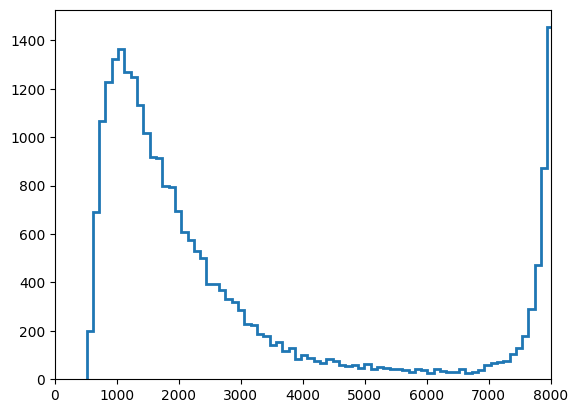

In [45]:
import importlib

import matplotlib.pyplot as plt

importlib.reload(plt)

plt.hist(lhe_mass, bins=100, histtype="step", linewidth=2)

plt.xlim(0, 8000)

plt.show()